# Lab Session: Generative Adversarial Network (GAN) on MNIST

**Name:** Ayush Saroj  
**Roll No:** 202401100400068  
**Lab:** 8

---

## Objective
- Understand the architecture of a GAN (Generator + Discriminator)
- Train a Vanilla GAN on the MNIST dataset to generate handwritten digit images
- Visualize training loss curves and generated image outputs

---

## Theory

A **Generative Adversarial Network (GAN)** consists of two neural networks that compete against each other:

| Component | Role |
|-----------|------|
| **Generator (G)** | Takes random noise `z` → generates fake images |
| **Discriminator (D)** | Takes an image (real or fake) → predicts Real or Fake |

They are trained simultaneously in a minimax game:
- **D** tries to correctly classify real vs fake
- **G** tries to fool D into thinking its outputs are real

**Objective Functions:**

$$\mathcal{L}_D = -[\log D(x) + \log(1 - D(G(z)))]$$

$$\mathcal{L}_G = -\log D(G(z))$$

**Dataset:** MNIST — 60,000 grayscale images of handwritten digits (0–9), each 28×28 pixels

---
## Step 1: Import Libraries

In [10]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torchvision.utils import make_grid
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np

print("PyTorch Version :", torch.__version__)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using Device    :", device)

PyTorch Version : 2.10.0+cu128
Using Device    : cuda


---
## Step 2: Hyperparameters

In [11]:
# --- Hyperparameters ---
lr          = 0.0002   # Learning rate for Adam optimizer
z_dim       = 100      # Latent noise vector dimension
batch_size  = 64       # Samples per batch
epochs      = 10       # Total training epochs
image_size  = 784      # 28x28 flattened

print(f"Learning Rate : {lr}")
print(f"Latent Dim    : {z_dim}")
print(f"Batch Size    : {batch_size}")
print(f"Epochs        : {epochs}")

Learning Rate : 0.0002
Latent Dim    : 100
Batch Size    : 64
Epochs        : 10


---
## Step 3: Load and Explore MNIST Dataset

In [12]:
# Normalize images to [-1, 1] to match Generator's Tanh output
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

dataset = datasets.MNIST(root="dataset/", train=True, transform=transform, download=True)
loader  = DataLoader(dataset, batch_size=batch_size, shuffle=True)

print(f"Total training samples : {len(dataset)}")
print(f"Number of batches      : {len(loader)}")
print(f"Image shape            : {dataset[0][0].shape}")

Total training samples : 60000
Number of batches      : 938
Image shape            : torch.Size([1, 28, 28])


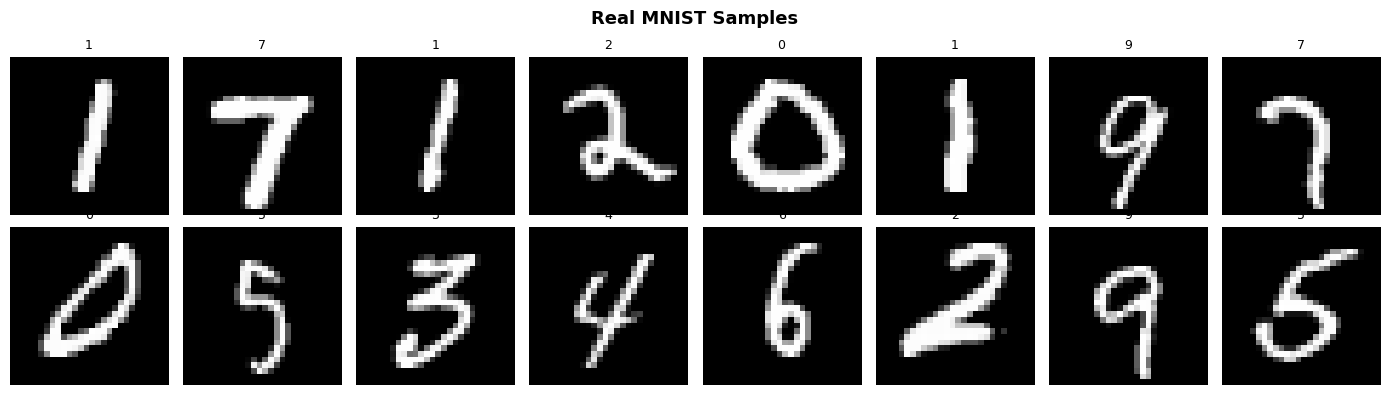

In [13]:
# Visualize some real MNIST samples
real_samples, labels = next(iter(loader))

fig, axes = plt.subplots(2, 8, figsize=(14, 4))
for i, ax in enumerate(axes.flatten()):
    img = real_samples[i].squeeze().numpy()
    img = (img + 1) / 2  # Rescale [-1,1] -> [0,1] for display
    ax.imshow(img, cmap='gray')
    ax.set_title(f"{labels[i].item()}", fontsize=9)
    ax.axis('off')
plt.suptitle("Real MNIST Samples", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## Step 4: Define the Discriminator

The **Discriminator** is a binary classifier:  
- Input: flattened image (784,)
- Output: single probability (real=1, fake=0)
- Uses **LeakyReLU** to allow small gradients for negative inputs

In [14]:
class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.disc = nn.Sequential(
            nn.Linear(784, 256),
            nn.LeakyReLU(0.1),
            nn.Dropout(0.3),
            nn.Linear(256, 128),
            nn.LeakyReLU(0.1),
            nn.Dropout(0.3),
            nn.Linear(128, 1),
            nn.Sigmoid(),           # Output: probability [0, 1]
        )

    def forward(self, x):
        return self.disc(x)

disc = Discriminator().to(device)
print("Discriminator Architecture:")
print(disc)
total_params = sum(p.numel() for p in disc.parameters())
print(f"\nTotal Parameters: {total_params:,}")

Discriminator Architecture:
Discriminator(
  (disc): Sequential(
    (0): Linear(in_features=784, out_features=256, bias=True)
    (1): LeakyReLU(negative_slope=0.1)
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=256, out_features=128, bias=True)
    (4): LeakyReLU(negative_slope=0.1)
    (5): Dropout(p=0.3, inplace=False)
    (6): Linear(in_features=128, out_features=1, bias=True)
    (7): Sigmoid()
  )
)

Total Parameters: 233,985


---
## Step 5: Define the Generator

The **Generator** maps random noise → fake images:  
- Input: noise vector `z` of size `z_dim=100`
- Output: flattened image (784,) with values in **[-1, 1]** via Tanh
- Uses **LeakyReLU** in hidden layers

In [15]:
class Generator(nn.Module):
    def __init__(self, z_dim):
        super().__init__()
        self.gen = nn.Sequential(
            nn.Linear(z_dim, 256),
            nn.LeakyReLU(0.1),
            nn.Linear(256, 512),
            nn.LeakyReLU(0.1),
            nn.Linear(512, 784),
            nn.Tanh(),              # Output: [-1, 1] to match normalized MNIST
        )

    def forward(self, z):
        return self.gen(z)

gen = Generator(z_dim).to(device)
print("Generator Architecture:")
print(gen)
total_params = sum(p.numel() for p in gen.parameters())
print(f"\nTotal Parameters: {total_params:,}")

Generator Architecture:
Generator(
  (gen): Sequential(
    (0): Linear(in_features=100, out_features=256, bias=True)
    (1): LeakyReLU(negative_slope=0.1)
    (2): Linear(in_features=256, out_features=512, bias=True)
    (3): LeakyReLU(negative_slope=0.1)
    (4): Linear(in_features=512, out_features=784, bias=True)
    (5): Tanh()
  )
)

Total Parameters: 559,632


---
## Step 6: Initialize Optimizers and Loss Function

In [16]:
# Separate Adam optimizers for G and D
opt_gen  = optim.Adam(gen.parameters(),  lr=lr, betas=(0.5, 0.999))
opt_disc = optim.Adam(disc.parameters(), lr=lr, betas=(0.5, 0.999))

# Binary Cross Entropy Loss
criterion = nn.BCELoss()

# Fixed noise to track Generator progress across epochs
fixed_noise = torch.randn(16, z_dim).to(device)

print("Optimizers and loss function initialized.")
print("BCELoss: L = -[y*log(p) + (1-y)*log(1-p)]")

Optimizers and loss function initialized.
BCELoss: L = -[y*log(p) + (1-y)*log(1-p)]


---
## Step 7: Training Loop

Each iteration:
1. **Train Discriminator** on real images (label=1) and fake images (label=0)
2. **Train Generator** to make Discriminator output 1 for fake images

In [17]:
G_losses = []  # Track generator loss per epoch
D_losses = []  # Track discriminator loss per epoch

print("Starting GAN Training...\n")
print(f"{'Epoch':>6} | {'Loss D':>8} | {'Loss G':>8}")
print("-" * 30)

for epoch in range(epochs):
    epoch_lossD = 0
    epoch_lossG = 0
    num_batches = 0

    for batch_idx, (real, _) in enumerate(loader):
        real       = real.view(-1, 784).to(device)
        batch_curr = real.shape[0]

        # ─────────────────────────────────────
        # Train Discriminator
        # max log(D(x)) + log(1 - D(G(z)))
        # ─────────────────────────────────────
        noise     = torch.randn(batch_curr, z_dim).to(device)
        fake      = gen(noise).detach()  # detach so G gradients are not computed here

        disc_real = disc(real).view(-1)
        lossD_real = criterion(disc_real, torch.ones_like(disc_real))

        disc_fake  = disc(fake).view(-1)
        lossD_fake = criterion(disc_fake, torch.zeros_like(disc_fake))

        lossD = (lossD_real + lossD_fake) / 2
        disc.zero_grad()
        lossD.backward()
        opt_disc.step()

        # ─────────────────────────────────────
        # Train Generator
        # max log(D(G(z)))  i.e. fool the discriminator
        # ─────────────────────────────────────
        noise  = torch.randn(batch_curr, z_dim).to(device)
        fake   = gen(noise)
        output = disc(fake).view(-1)
        lossG  = criterion(output, torch.ones_like(output))

        gen.zero_grad()
        lossG.backward()
        opt_gen.step()

        epoch_lossD += lossD.item()
        epoch_lossG += lossG.item()
        num_batches += 1

    avg_lossD = epoch_lossD / num_batches
    avg_lossG = epoch_lossG / num_batches
    D_losses.append(avg_lossD)
    G_losses.append(avg_lossG)

    if (epoch + 1) % 5 == 0 or epoch == 0:
        print(f"{epoch+1:>6} | {avg_lossD:>8.4f} | {avg_lossG:>8.4f}")

print("\nTraining Complete!")

Starting GAN Training...

 Epoch |   Loss D |   Loss G
------------------------------
     1 |   0.4445 |   1.4145
     5 |   0.2597 |   2.4279
    10 |   0.4117 |   1.6469

Training Complete!


---
## Step 8: Plot Training Loss Curves

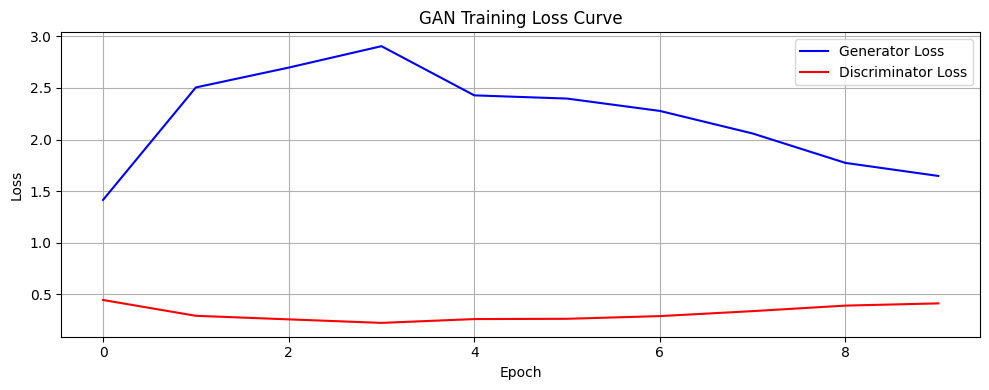


Final Generator Loss     : 1.6469
Final Discriminator Loss : 0.4117


In [18]:
plt.figure(figsize=(10, 4))
plt.plot(G_losses, label='Generator Loss',     color='blue')
plt.plot(D_losses, label='Discriminator Loss', color='red')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('GAN Training Loss Curve')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

print(f"\nFinal Generator Loss     : {G_losses[-1]:.4f}")
print(f"Final Discriminator Loss : {D_losses[-1]:.4f}")

---
## Step 9: Visualize Generated Images

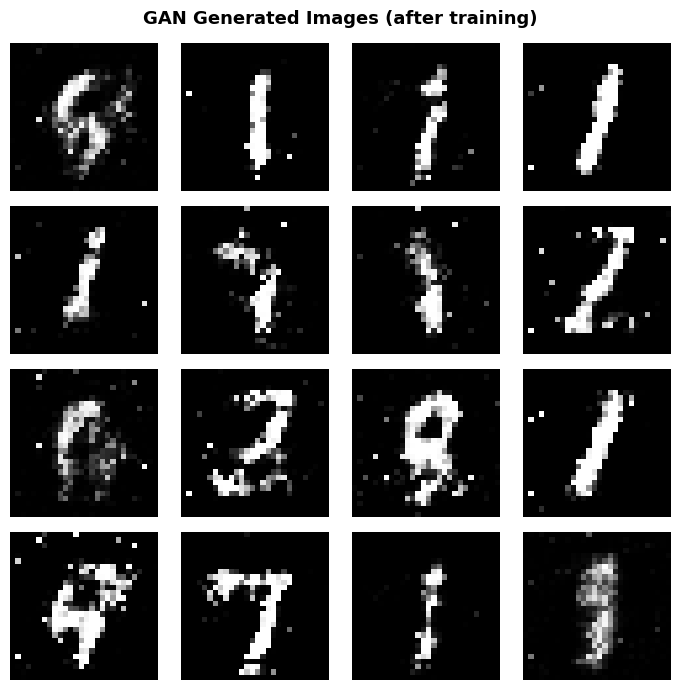

In [19]:
# Generate images using the fixed noise (same noise every time = comparable progress)
gen.eval()
with torch.no_grad():
    fake_images = gen(fixed_noise).reshape(-1, 1, 28, 28)
    fake_images = (fake_images + 1) / 2  # Rescale [-1,1] -> [0,1]

fig, axes = plt.subplots(4, 4, figsize=(7, 7))
for i, ax in enumerate(axes.flatten()):
    ax.imshow(fake_images[i].squeeze().cpu().numpy(), cmap='gray')
    ax.axis('off')
plt.suptitle("GAN Generated Images (after training)", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## Step 10: Compare Real vs Generated Images

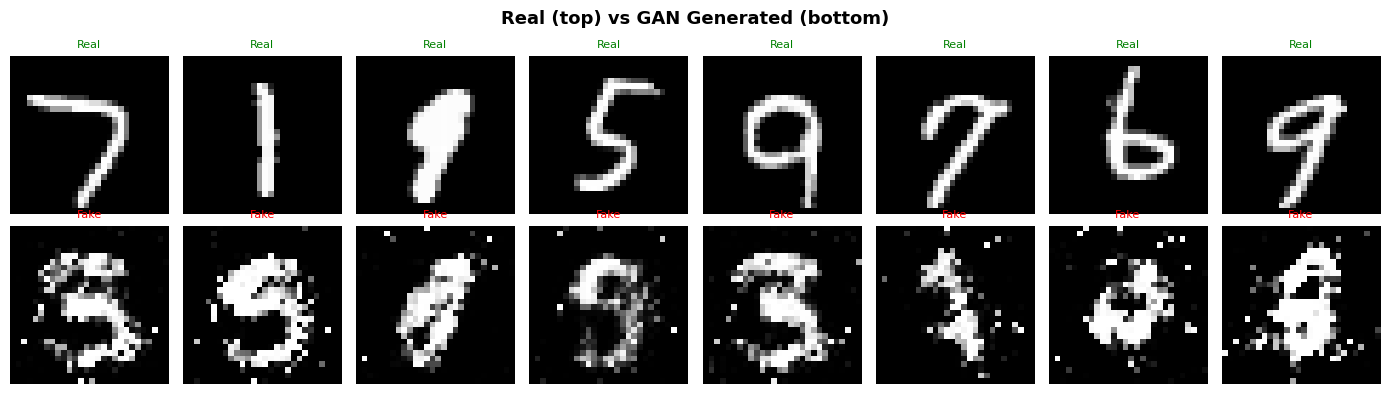

In [20]:
# Side-by-side comparison
real_batch, _ = next(iter(loader))
real_imgs     = (real_batch[:8] + 1) / 2  # Rescale

gen.eval()
with torch.no_grad():
    noise_sample = torch.randn(8, z_dim).to(device)
    fake_imgs    = gen(noise_sample).reshape(-1, 1, 28, 28)
    fake_imgs    = (fake_imgs + 1) / 2

fig, axes = plt.subplots(2, 8, figsize=(14, 4))

for i in range(8):
    axes[0, i].imshow(real_imgs[i].squeeze().cpu().numpy(), cmap='gray')
    axes[0, i].set_title('Real', fontsize=8, color='green')
    axes[0, i].axis('off')

    axes[1, i].imshow(fake_imgs[i].squeeze().cpu().numpy(), cmap='gray')
    axes[1, i].set_title('Fake', fontsize=8, color='red')
    axes[1, i].axis('off')

plt.suptitle("Real (top) vs GAN Generated (bottom)", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## Step 11: Explore the Latent Space

By interpolating between two noise vectors, we can see smooth transitions between generated digits.

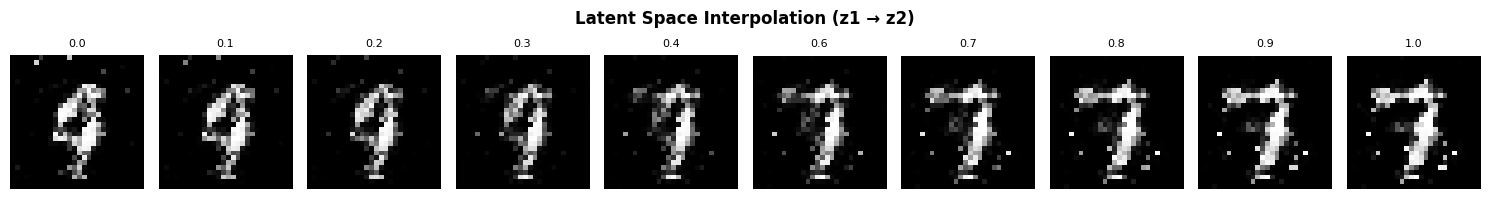

In [21]:
# Interpolate between two random noise vectors
gen.eval()
with torch.no_grad():
    z1 = torch.randn(1, z_dim).to(device)
    z2 = torch.randn(1, z_dim).to(device)

    steps      = 10
    alphas     = np.linspace(0, 1, steps)
    interp_imgs = []

    for alpha in alphas:
        z_interp = (1 - alpha) * z1 + alpha * z2
        img      = gen(z_interp).reshape(1, 28, 28)
        img      = (img + 1) / 2
        interp_imgs.append(img.squeeze().cpu().numpy())

fig, axes = plt.subplots(1, steps, figsize=(15, 2))
for i, ax in enumerate(axes):
    ax.imshow(interp_imgs[i], cmap='gray')
    ax.set_title(f"{alphas[i]:.1f}", fontsize=8)
    ax.axis('off')
plt.suptitle("Latent Space Interpolation (z1 → z2)", fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

---
## Summary

| Component | Details |
|-----------|--------|
| Dataset | MNIST (60,000 images, 28×28, grayscale) |
| Generator Input | Random noise vector (z_dim = 100) |
| Generator Output | 784-dim vector → 28×28 image |
| Discriminator Input | 784-dim flattened image |
| Discriminator Output | Probability (Real=1, Fake=0) |
| Loss Function | Binary Cross Entropy (BCELoss) |
| Optimizer | Adam (lr=0.0002, betas=(0.5, 0.999)) |
| Epochs | 10 |

### Key Observations
- Early epochs: Generator produces noisy, unrecognizable images
- After training: Generator produces digit-like images that can fool the Discriminator
- Loss D ≈ 0.5 and Loss G ≈ 0.7 at convergence indicates a good equilibrium
- Latent space interpolation shows smooth transitions between generated samples